|                |   |
:----------------|---|
| **Nombre**     | Elisa Aguirre Arias  |
| **Fecha**      | 26/03/2026  |
| **Expediente** | 738894 |

In [1]:
import pandas as pd 
import numpy as np
from sklearn.neural_network import MLPClassifier

In [2]:
df= pd.read_csv(r"C:\Users\elisa\Downloads\Heart Prediction Quantum Dataset.csv")
df.head()

,Age,Gender,BloodPressure,Cholesterol,HeartRate,QuantumPatternFeature,HeartDisease
0,68,1,105,191,107,8.362241,1
1,58,0,97,249,89,9.249002,0
2,44,0,93,190,82,7.942542,1
3,72,1,93,183,101,6.495155,1
4,37,0,145,166,103,7.653900,1


##  Ver tipos de datos

In [3]:
df.dtypes

Age                        int64
Gender                     int64
BloodPressure              int64
Cholesterol                int64
HeartRate                  int64
QuantumPatternFeature    float64
HeartDisease               int64
dtype: object

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    500 non-null    int64  
 1   Gender                 500 non-null    int64  
 2   BloodPressure          500 non-null    int64  
 3   Cholesterol            500 non-null    int64  
 4   HeartRate              500 non-null    int64  
 5   QuantumPatternFeature  500 non-null    float64
 6   HeartDisease           500 non-null    int64  
dtypes: float64(1), int64(6)
memory usage: 27.5 KB


In [5]:
df.describe()

,Age,Gender,BloodPressure,Cholesterol,HeartRate,QuantumPatternFeature,HeartDisease
count,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.000000
mean,54.864000,0.468000,132.874000,221.50000,88.766000,8.317407,0.600000
std,14.315004,0.499475,26.418516,43.86363,17.417289,0.919629,0.490389
min,30.000000,0.000000,90.000000,150.00000,60.000000,6.164692,0.000000
25%,43.000000,0.000000,111.000000,183.75000,73.000000,7.675779,0.000000
50%,55.000000,0.000000,132.000000,221.00000,89.000000,8.323064,1.000000
75%,66.250000,1.000000,155.000000,258.00000,104.000000,8.935999,1.000000
max,79.000000,1.000000,179.000000,299.00000,119.000000,10.784886,1.000000


In [4]:
df = df.drop("QuantumPatternFeature", axis=1)

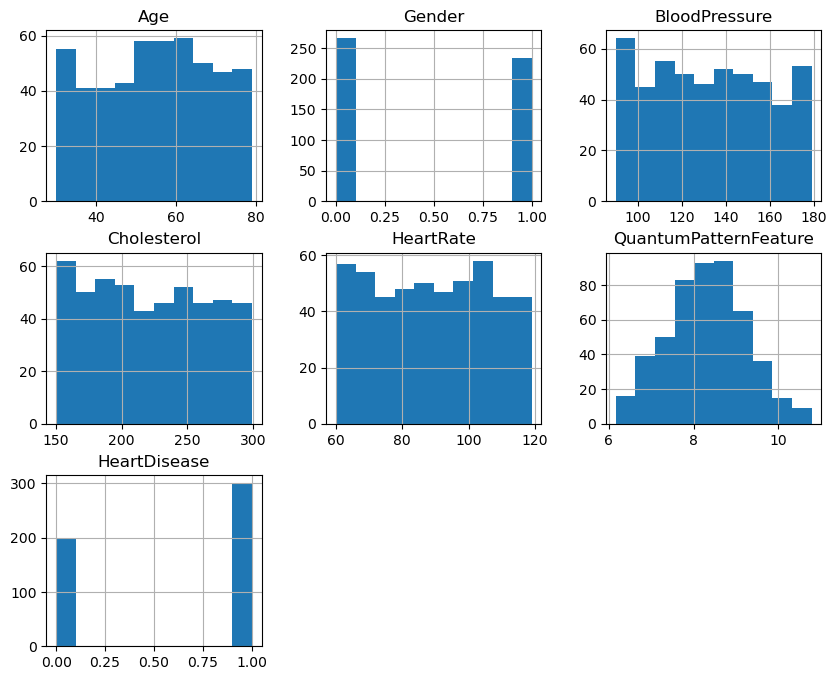

In [6]:
import matplotlib.pyplot as plt

df.hist(figsize=(10,8))
plt.show()

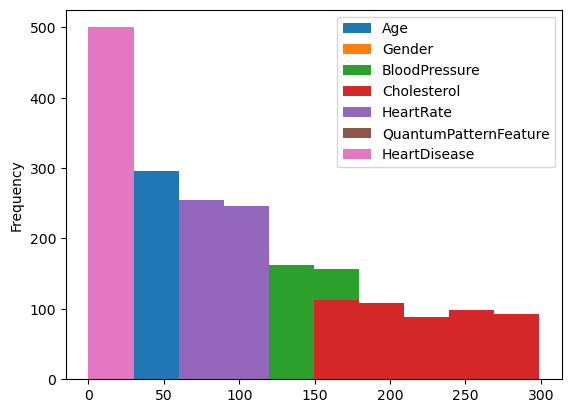

In [7]:
df.plot.hist()
plt.show()

##  Definir X y Y

In [8]:
target_col = "HeartDisease"
num_cols = ["Age", "BloodPressure", "Cholesterol", "HeartRate"]
cat_cols = ["Gender"]

In [9]:
X = df[num_cols + cat_cols]
y = df[target_col]

In [10]:
from sklearn.preprocessing import StandardScaler

num_transformer = StandardScaler()

In [11]:
hidden_layer_sizes=(5,10)
model=MLPClassifier(hidden_layer_sizes=hidden_layer_sizes,random_state=42)

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_cols)
    ])

pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", model)
])

In [13]:
pipeline.fit(X, y)

C:\Users\elisa\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'BloodPressure',
                                                   'Cholesterol',
                                                   'HeartRate'])])),
                ('model',
                 MLPClassifier(hidden_layer_sizes=(5, 10), random_state=42))])

In [14]:
pipeline.score(X,y)

0.778

In [15]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(pipeline, X, y, cv=10, scoring="roc_auc_ovo")

C:\Users\elisa\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\elisa\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\elisa\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\elisa\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\elisa\anaconda3\Lib\site-packages\sklearn\neural_network\_multi

In [16]:
print("AUC scores:", scores)

AUC scores: [0.84833333 0.86666667 0.76666667 0.855      0.64666667 0.88666667
 0.87333333 0.81833333 0.855      0.87333333]


In [17]:
print("AUC promedio:", scores.mean())

AUC promedio: 0.8290000000000001


# Optimización bayesiana

In [18]:
import numpy as np
from sklearn.neural_network import MLPClassifier
from sklearn.gaussian_process import GaussianProcessRegressor

In [19]:
def f(neurons):
    n = int(neurons[0])
    hidden_layer = (n, n)
    model = MLPClassifier(hidden_layer_sizes=hidden_layer, random_state=42, max_iter=1000)
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model),
    ])
    scores = cross_val_score(pipeline, X, y, scoring='roc_auc_ovo', cv=10)
    return np.mean(scores)

In [20]:
X_gp = np.array([[5], [10], [20]])
y_gp = np.array([f([5]), f([10]), f([20])])

C:\Users\elisa\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\elisa\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\elisa\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\elisa\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\elisa\anaconda3\Lib\site-packages\sklearn\neural_network\_m

In [21]:
gp = GaussianProcessRegressor(random_state=42)

In [22]:
X_sim = np.linspace(5, 30, 50).reshape(-1,1)

In [23]:
for i in range(10):
    gp.fit(X_gp, y_gp)
    y_pred = gp.predict(X_sim)
    i_max = np.argmax(y_pred)
    x_new = X_sim[i_max]
    y_new = f(x_new)
    X_gp = np.vstack((X_gp, x_new))
    y_gp = np.append(y_gp, y_new)
    print(f"Iteración {i+1}: neuronas={int(x_new[0])}, AUC={y_new}")

Iteración 1: neuronas=5, AUC=0.8453333333333333
Iteración 2: neuronas=5, AUC=0.8453333333333333
Iteración 3: neuronas=5, AUC=0.8453333333333333
Iteración 4: neuronas=5, AUC=0.8453333333333333
Iteración 5: neuronas=5, AUC=0.8453333333333333
Iteración 6: neuronas=5, AUC=0.8453333333333333
Iteración 7: neuronas=5, AUC=0.8453333333333333
Iteración 8: neuronas=5, AUC=0.8453333333333333
Iteración 9: neuronas=5, AUC=0.8453333333333333
Iteración 10: neuronas=5, AUC=0.8453333333333333


In [24]:
best_index = np.argmax(y_gp)

print("Mejor resultado:")
print("Neuronas:", int(X_gp[best_index][0]))
print("AUC:", y_gp[best_index])

Mejor resultado:
Neuronas: 10
AUC: 0.8459999999999999
